In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv(r'../data/raw/ecommerce_price_prediction-train.csv')

# Display basic structural info
print("--- Dataset Information ---")
print(df.info())

print("\n--- Missing Values per Column ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 306226 entries, 0 to 306225
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   capturedAt                306226 non-null  str    
 1   shopId                    306226 non-null  int64  
 2   itemId                    306226 non-null  int64  
 3   modelId                   306226 non-null  int64  
 4   price                     306226 non-null  int64  
 5   priceBeforeDiscount       306226 non-null  int64  
 6   promotionId               306226 non-null  int64  
 7   cat_id                    306226 non-null  int64  
 8   stock                     3738 non-null    float64
 9   normal_stock              3738 non-null    float64
 10  raw_discount              306226 non-null  int64  
 11  show_discount             306226 non-null  int64  
 12  brand                     200562 non-null  str    
 13  is_free_shipping          3

--- Target Variable Descriptive Statistics ---
count    3.062260e+05
mean     5.234146e+07
std      9.137196e+07
min      1.000000e+05
25%      9.900000e+06
50%      2.050000e+07
75%      5.900000e+07
max      1.660000e+09
Name: price, dtype: float64


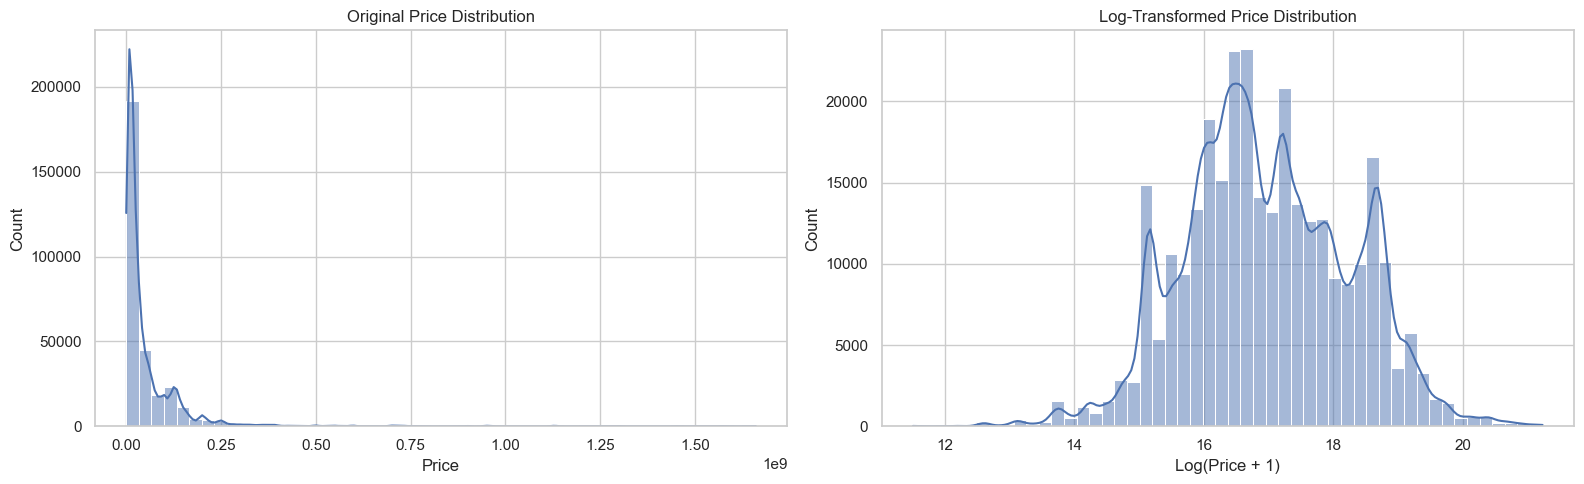


Number of rows with price <= 0: 0


In [2]:
print("--- Target Variable Descriptive Statistics ---")
print(df['price'].describe())

# Plot original vs log-transformed price distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price')

sns.histplot(np.log1p(df['price']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

# Check for non-positive prices
invalid_prices = df[df['price'] <= 0]
print(f"\nNumber of rows with price <= 0: {len(invalid_prices)}")

In [3]:
print("--- Unique Cardinality Count ---")
categorical_features = ['shopId', 'itemId', 'modelId', 'cat_id', 'brand']

for col in categorical_features:
    unique_count = df[col].nunique()
    print(f"Unique count for '{col}': {unique_count}")

# Distribution of product samples per shop
shop_distribution = df['shopId'].value_counts()
print("\n--- Data Point Distribution per Shop ---")
print(shop_distribution.describe())

--- Unique Cardinality Count ---
Unique count for 'shopId': 219
Unique count for 'itemId': 1594
Unique count for 'modelId': 6286
Unique count for 'cat_id': 26
Unique count for 'brand': 376

--- Data Point Distribution per Shop ---
count      219.000000
mean      1398.292237
std       4442.709664
min          1.000000
25%         61.500000
50%        228.000000
75%        869.000000
max      52925.000000
Name: count, dtype: float64


In [4]:
print("--- Pricing Logic Validation ---")

# Rule 1: Price should not exceed priceBeforeDiscount when a discount exists
discounted_items = df[df['priceBeforeDiscount'] > 0]
price_anomaly_count = len(discounted_items[discounted_items['price'] > discounted_items['priceBeforeDiscount']])
print(f"Rows where current price > priceBeforeDiscount: {price_anomaly_count}")

# Rule 2: Price must fall within item_price_min and item_price_max boundaries
out_of_bounds_count = len(df[(df['price'] < df['item_price_min']) | (df['price'] > df['item_price_max'])])
print(f"Rows where price falls outside [item_price_min, item_price_max]: {out_of_bounds_count}")

--- Pricing Logic Validation ---
Rows where current price > priceBeforeDiscount: 0
Rows where price falls outside [item_price_min, item_price_max]: 10444


--- Temporal Range ---
Training Data Timeline: 2025-01-01 to 2025-03-22


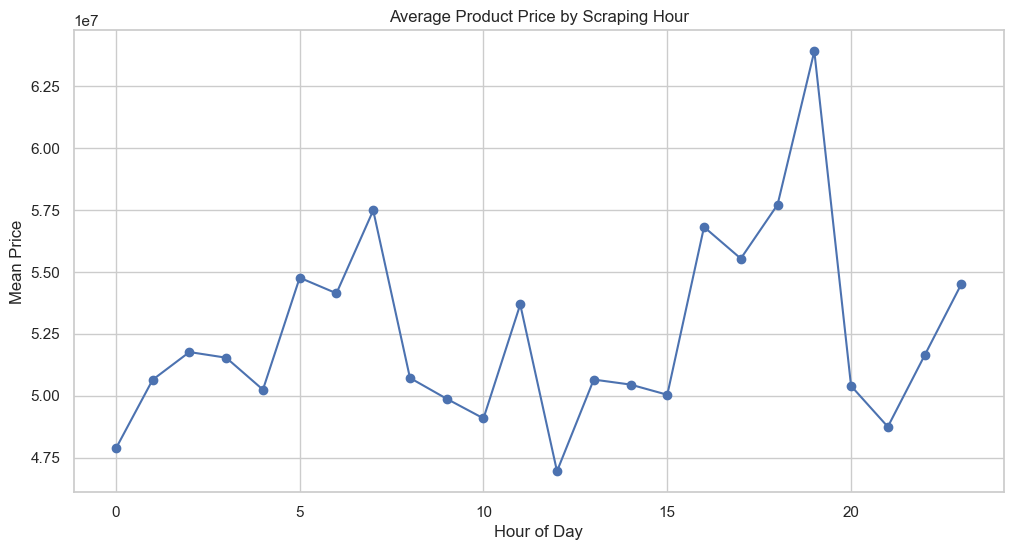

In [5]:
# Convert to datetime object
df['capturedAt'] = pd.to_datetime(df['capturedAt'])

# Extract base temporal features
df['hour'] = df['capturedAt'].dt.hour
df['day_of_week'] = df['capturedAt'].dt.dayofweek
df['scrape_date'] = df['capturedAt'].dt.date

print("--- Temporal Range ---")
print(f"Training Data Timeline: {df['scrape_date'].min()} to {df['scrape_date'].max()}")

# Visualize average price fluctuation by scraping hour
df.groupby('hour')['price'].mean().plot(kind='line', marker='o', color='b')
plt.title('Average Product Price by Scraping Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Price')
plt.grid(True)
plt.show()

--- Correlation with Log-Price ---
log_price              1.000000
item_price_max         0.703405
item_price_min         0.665012
priceBeforeDiscount    0.189500
shop_response_rate     0.033395
hour                   0.015835
shop_rating           -0.010351
cmt_count             -0.108442
total_rating_count    -0.114293
review_rating         -0.114994
shop_follower_count   -0.142508
show_discount         -0.273873
raw_discount          -0.273873
Name: log_price, dtype: float64


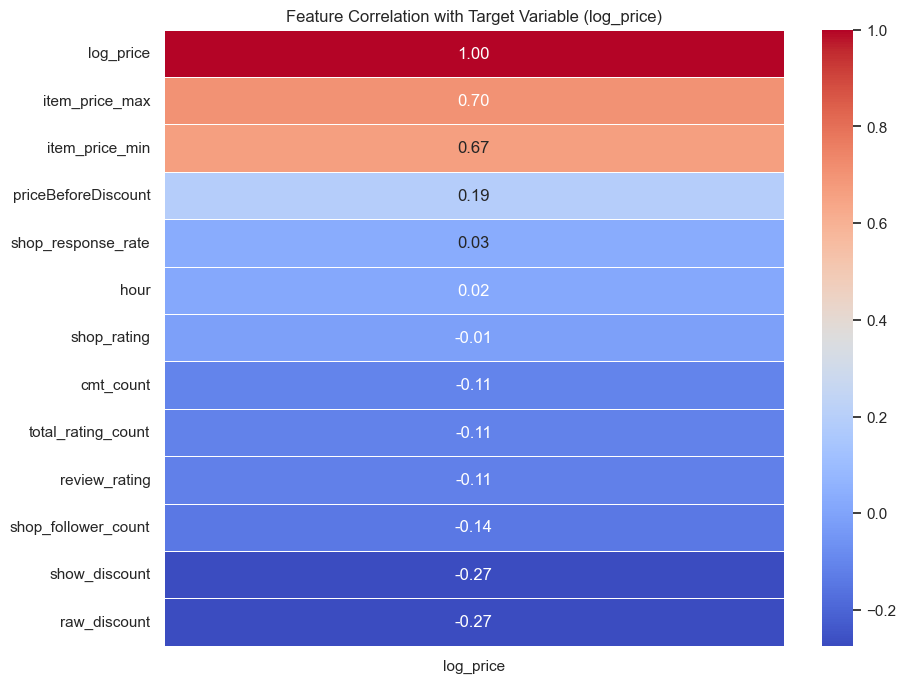

In [6]:
# Create the optimized target variable for analysis
df['log_price'] = np.log1p(df['price'])

# Select numerical columns for correlation analysis
numerical_cols = [
    'log_price', 'priceBeforeDiscount', 'raw_discount', 'show_discount',
    'item_price_min', 'item_price_max', 'review_rating', 
    'total_rating_count', 'cmt_count', 'shop_rating', 
    'shop_response_rate', 'shop_follower_count', 'hour'
]

# Calculate Pearson Correlation Matrix
corr_matrix = df[numerical_cols].corr()

# Plot Correlation Heatmap targeting 'log_price'
print("--- Correlation with Log-Price ---")
print(corr_matrix['log_price'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[['log_price']].sort_values(by='log_price', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation with Target Variable (log_price)')
plt.show()

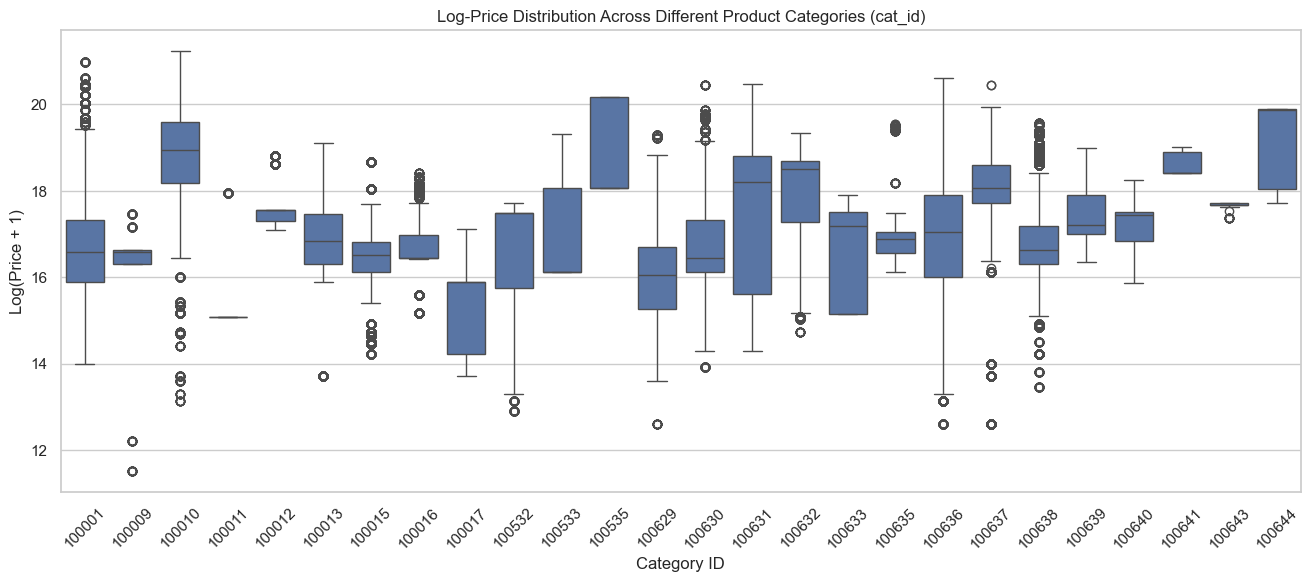

In [7]:
# Boxplot to see price distribution variations across categories
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='cat_id', y='log_price')
plt.title('Log-Price Distribution Across Different Product Categories (cat_id)')
plt.xlabel('Category ID')
plt.ylabel('Log(Price + 1)')
plt.xticks(rotation=45)
plt.show()

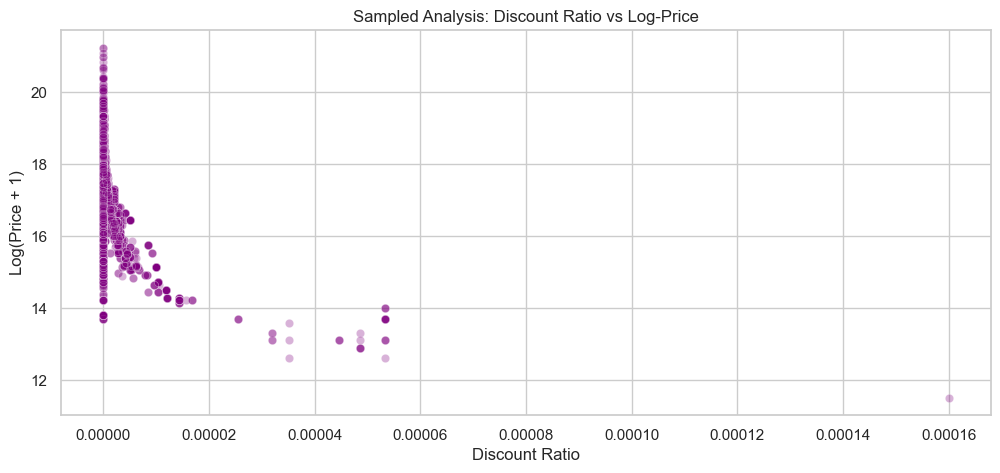

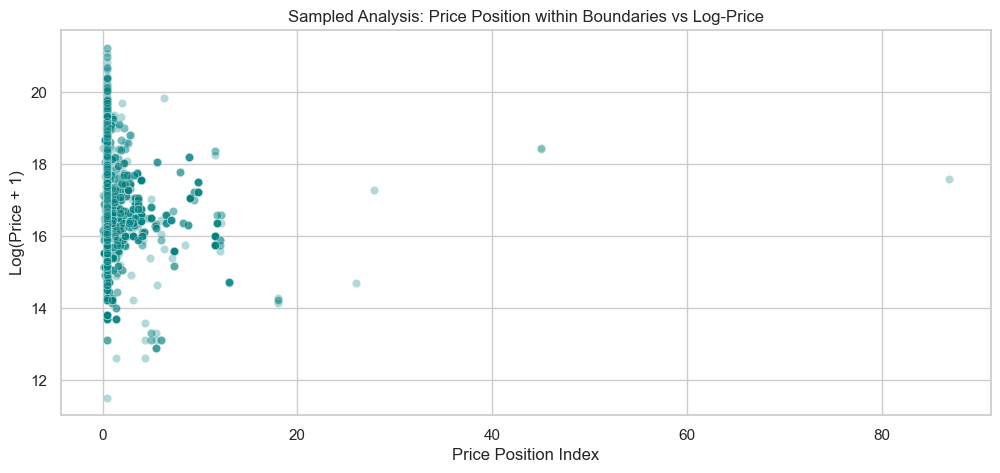

In [ ]:
# 1. Perbaikan Kedalaman Diskon (Jika priceBeforeDiscount <= 0, langsung beri rasio 0)
df['discount_ratio'] = np.where(
    df['priceBeforeDiscount'] > 0, 
    df['raw_discount'] / df['priceBeforeDiscount'], 
    0.0
)

# 2. Perbaikan Posisi Harga (Kunci batas bawah penyebut agar tidak terjadi pembagian hantu)
price_range = df['item_price_max'] - df['item_price_min']

df['price_position'] = np.where(
    (price_range > 0) & (df['priceBeforeDiscount'] > 0),
    (df['priceBeforeDiscount'] - df['item_price_min']) / price_range,
    0.5 # Jika harga min & max sama, taruh posisinya di tengah (0.5) sebagai fallback aman
)

# Visualizing the relationship between Discount Ratio and Log-Price
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='discount_ratio', y='log_price', alpha=0.3, color='purple')
plt.title('Sampled Analysis: Discount Ratio vs Log-Price')
plt.xlabel('Discount Ratio')
plt.ylabel('Log(Price + 1)')
plt.show()

# Visualizing how Price Position maps against the actual Log-Price
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='price_position', y='log_price', alpha=0.3, color='teal')
plt.title('Sampled Analysis: Price Position within Boundaries vs Log-Price')
plt.xlabel('Price Position Index')
plt.ylabel('Log(Price + 1)')
plt.show()

In [9]:
# Fixed Price Position Formula to prevent division overflow
denominator = df['item_price_max'] - df['item_price_min']
df['price_position'] = np.where(
    denominator == 0, 
    0.5, # Default to center if min equals max
    (df['priceBeforeDiscount'] - df['item_price_min']) / (denominator + 1e-5)
)

# Fixed Discount Ratio to prevent division by zero when priceBeforeDiscount is 0
df['discount_ratio'] = np.where(
    df['priceBeforeDiscount'] == 0,
    0.0,
    df['raw_discount'] / (df['priceBeforeDiscount'] + 1e-5)
)

print("--- Cleaned Feature Bounds ---")
print(df[['price_position', 'discount_ratio']].describe())

--- Cleaned Feature Bounds ---
       price_position  discount_ratio
count   306226.000000   306226.000000
mean        -0.685369        0.000001
std          6.573444        0.000005
min       -131.500000        0.000000
25%         -0.625000        0.000000
50%          0.500000        0.000000
75%          0.500000        0.000001
max         86.833333        0.000160


# Exploratory Data Analysis (EDA) Summary & Strategic Alignment with MrScraper's Business Case

This document summarizes the critical findings from the exploratory data analysis (`01_eda.ipynb`) and translates them into a concrete technical strategy to solve the **MrScraper AI Engineer Take-Home Test (Price Intelligence & Anomaly Detection)**.

---

## 1. Problem Context Summary

When an e-commerce platform blocks scraping bots due to anti-scraping countermeasures or downtime, we lose real-time pricing visibility. The core challenge of this project is to accurately predict the missing prices for **76,255 rows (Test Set)** using a rich historical dataset of **306,226 rows (Train Set)**, leveraged by a tiny anchor set of **100 manually collected prices** on the affected outage day to calibrate platform-wide price shifts.

---

## 2. Key EDA Findings & Technical Action Plans

### A. Missing Values Analysis: Stock Data Sparsity

* **EDA Finding:** The `stock` and `normal_stock` columns suffer from an extreme missing data rate of **98.7%** (only 3,738 rows are populated out of the 306,226 total rows).
* **Realistic Root Cause:** E-commerce platforms often hide stock levels behind interactive UI elements or require specific user authentication, causing the scraper bot to fail to capture this field during automated runs.
* **ML Action Plan:**
  * **Avoid Naive Imputation:** Filling missing values with the mean or median on a column that is 98.7% empty will heavily distort the original data distribution and mislead the model.
  * **Solution:** Drop these columns from the training features entirely, or convert them into a binary indicator flag (`is_stock_recorded`: 1 if data exists, 0 if null). This binary flag can help the model differentiate specific shop profiles to mitigate cold-start issues.

### B. Target Variable (`price`) Distribution: Extreme Right-Skew

* **EDA Finding:** The target variable `price` is highly skewed, ranging from a minimum of **100,000** to an astronomical maximum of **1,660,000,000 (1.66 Billion)**. The median sits at **20,500,000**, while the mean is pulled up to **52,341,460**.
* **Realistic Root Cause:** This reflects real-world e-commerce dynamics: the marketplace is heavily dominated by standard/low-cost goods (high volume, low price), but contains a tiny fraction of high-end luxury items or premium electronics that command massive price tags (long-tail distribution).
* **ML Action Plan:**
  * Standard machine learning algorithms (both Linear Regression and Tree-based models like XGBoost/LightGBM) will suffer severe bias because they natively try to minimize errors on high-magnitude numbers, sacrificing prediction accuracy on the lower-priced majority.
  * **Solution:** Apply a **Log Transformation** (`np.log1p(price)`) to the target variable before training to stabilize the variance and tame the outliers. Remember to inverse-transform the predictions using the exponential function (`np.expm1`) when evaluating metrics like MAE or RMSE.

### C. Historical Price Boundaries & Numerical Stability (`item_price_min` & `item_price_max`)

* **EDA Finding:** Boundary analysis reveals instances where the active product price breaks out of its historical minimum or maximum threshold bounds. Furthermore, items with no variant options show identical minimum and maximum historical prices (`item_price_min == item_price_max`).
* **Realistic Root Cause:** Out-of-bounds variations indicate aggressive platform-wide promotional events (like Flash Sales dropping prices below the historical minimum), rapid vendor inflation, or human data-entry typos. Identical bounds occur on single-variant listings.
* **ML Action Plan:**
  * Do not drop these anomaly rows. Instead, transform them into powerful predictive features by calculating deviation ratios: `price_to_min_ratio` ($Price / Price_{min}$) and `price_to_max_ratio` ($Price / Price_{max}$).
  * **Zero-Division Risk Mitigation:** When computing relative positioning within boundaries, a flat denominator (`item_price_max - item_price_min == 0`) will cause numerical overflow up to scales of $10^{14}$. We apply a conditional `np.where` vectorization vector to safely clamp single-variant items to a default baseline center (`0.5`) to prevent explosive tree-split distortions.

### D. Scraping Time Patterns: Temporal Sampling Bias

* **EDA Finding:** The graph for the average product price by scraping hour exhibits a highly cyclical pattern with sharp spikes at **7 AM, 11 AM, 4 PM**, and a massive peak at **7 PM** (~63.8 Million).
* **Realistic Root Cause:** E-commerce sellers do not collectively collude to raise prices at 7 PM. This is a classic symptom of **Sampling/Scraping Bias** within MrScraper's automated infrastructure. The bot's cron jobs were likely scheduled to target high-value categories (like luxury brands or premium electronics) specifically during those peak hours.
* **ML Action Plan:**
  * **Data Leakage & Overfitting Hazard:** The model must not interpret the `hour` feature rawly (e.g., assuming any item scraped at 7 PM automatically gains millions in value).
  * **Solution:** Create **Interaction Features** by crossing the time component with the category ID or shop ID (`hour` $\times$ `cat_id`). Force the model to treat the hour feature as a **Category Group Proxy** rather than a natural market price inflator. Additionally, apply cyclical encoding (Sine/Cosine transforms) to preserve continuous temporal boundaries.

---

## 3. Calibration Strategy Using the Anchor Set (100 Daily Samples)

The test instructions prompt us to think about how the 100 manual anchor samples can inform platform-wide shifts. Based on our EDA insights, here is the deployment strategy:

1. **Extract Global Deviation Trends:** Calculate how far the prices of the 100 anchor items deviate from their historical baseline metrics (`item_price_min` / `max`) on that specific outage day.
2. **Calibration Multiplier:** If the anchor set reveals that prices on the outage day shifted by an average of +5% across categories due to a platform-wide flash sale, we can inject this 1.05 multiplier adjustment to calibrate and fine-tune the global model's predictions across the remaining **76,255 Test Set rows**.

---

## 4. Modeling Pipeline Conclusion

| Pipeline Stage | Recommended Approach Based on EDA Findings |
|----------------------|------------------------------------------------|
| **Data Cleaning** | Drop `stock` & `normal_stock` columns (or convert them into a binary `0/1` missingness flag). Handle `brand` missingness by filling with an `'Unknown'` token. |
| **Target Preprocessing** | Apply a Log Transformation (`log1p`) to the `price` target variable before model training. |
| **Feature Engineering** | 1. Generate price deviation ratios against historical min/max boundaries with zero-division protection.<br>2. Build cross-features combining `hour` × `cat_id` to handle scraper scheduling bias.<br>3. Apply continuous cyclical encoding to temporal signals. |
| **Model Validation** | Implement a strict **Time-Series Split** based on `capturedAt` to simulate the outage day and prevent data leakage from the future into the past. |